# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['date'] = df.index.date
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [122]:
df['date'] = pd.to_datetime(df['date'])

In [123]:
quarter_map = {
    12:'1', 1:'1',2:'1',
    3:'2',4:'2',5:'2',
    6:'3',7:'3',8:'3',9:'3',
    10:'4',11:'4'
}

df['weather_season_india'] = df['date'].dt.month.map(quarter_map)

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [3]:
avg_rent = df['count'].resample('ME').agg('mean')

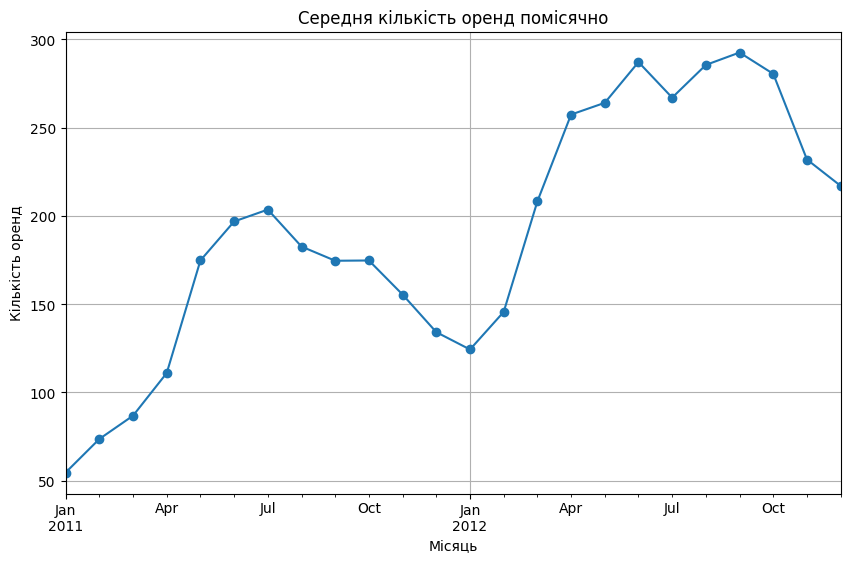

In [4]:
avg_rent.plot(
    marker = 'o',
    figsize=(10,6),
    title='Середня кількість оренд помісячно',
    xlabel='Місяць',
    ylabel='Кількість оренд',
    grid=True
);

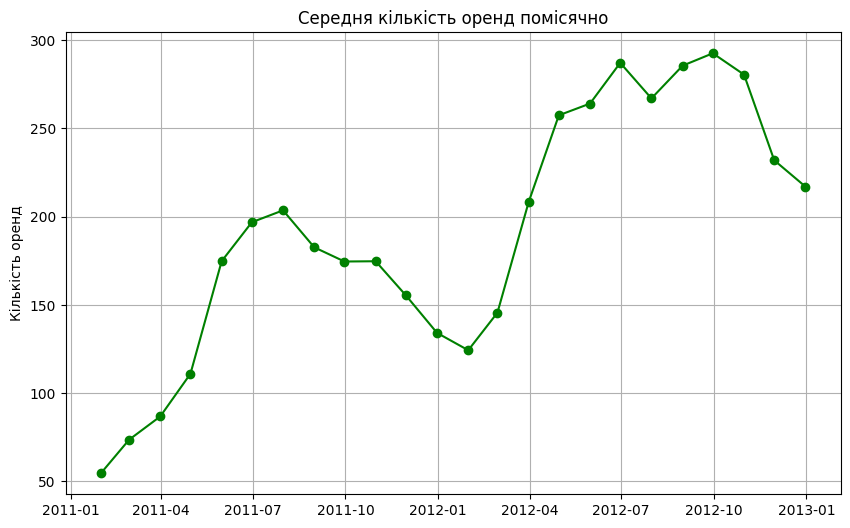

In [5]:
plt.figure(figsize=(10,6))
plt.plot(avg_rent,'o-g')

plt.title('Середня кількість оренд помісячно')
plt.ylabel('Кількість оренд')
plt.grid(True)
plt.show()

1. Графіки відрізняються  виглядом позначки місяця, різниця в сітці та те що лінійний графік не торкається до меж клітинок.
2. Перший код мені подобається більше, він оптимізованіший та більш структурний. Та другий, побудований з Matplotlib візуально прибавливіший , і звісно в нас є більше можливостей для ширшої кількості налаштувань. В кожному з них є переваги та недоліки. Портібно вміти працювати з обома і вдало іх застосовувати.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [35]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

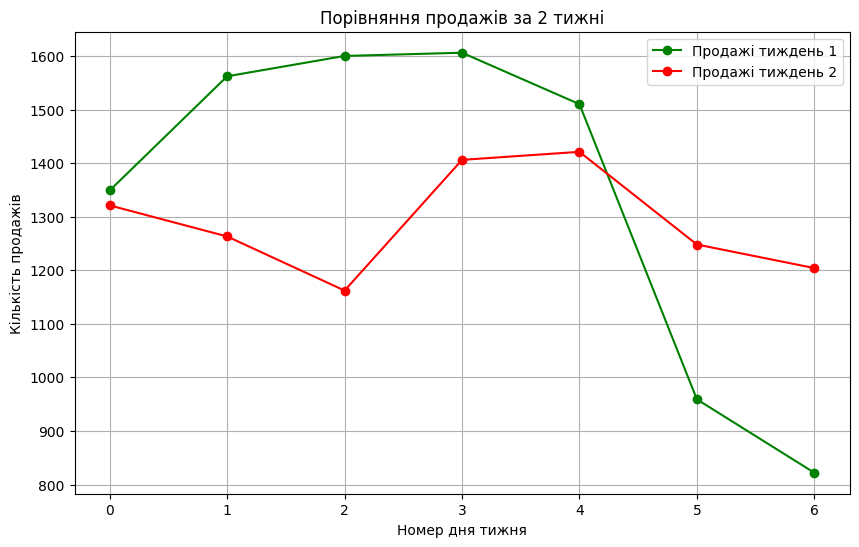

In [163]:
plt.figure(figsize=(10,6))
plt.plot(sales_week1,'o-g',label='Продажі тиждень 1')
plt.plot(sales_week2,'o-r',label='Продажі тиждень 2')

plt.title('Порівняння продажів за 2 тижні')
plt.xlabel('Номер дня тижня')
plt.ylabel('Кількість продажів')
plt.grid(True)
plt.legend()
plt.show()


1. Стабільніші продажі були на 2 тижні.
2. Нижче ми побачили результати обчислення стандартного відхилення за два тижні. І наша гіпотеза підтвердилась, дійсно 2 тиждень більш стабільний, тому що розкид продажів менший, вони є більш передбачувані та стабільні.

In [39]:
print(np.std(sales_week1))

299.99857142517004


In [40]:
print(np.std(sales_week2))

90.9060964256355


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [147]:
avg_temp = df['temp'].resample('ME').agg('mean')
avg_quarter= df.groupby(df.index.quarter)['count'].mean()

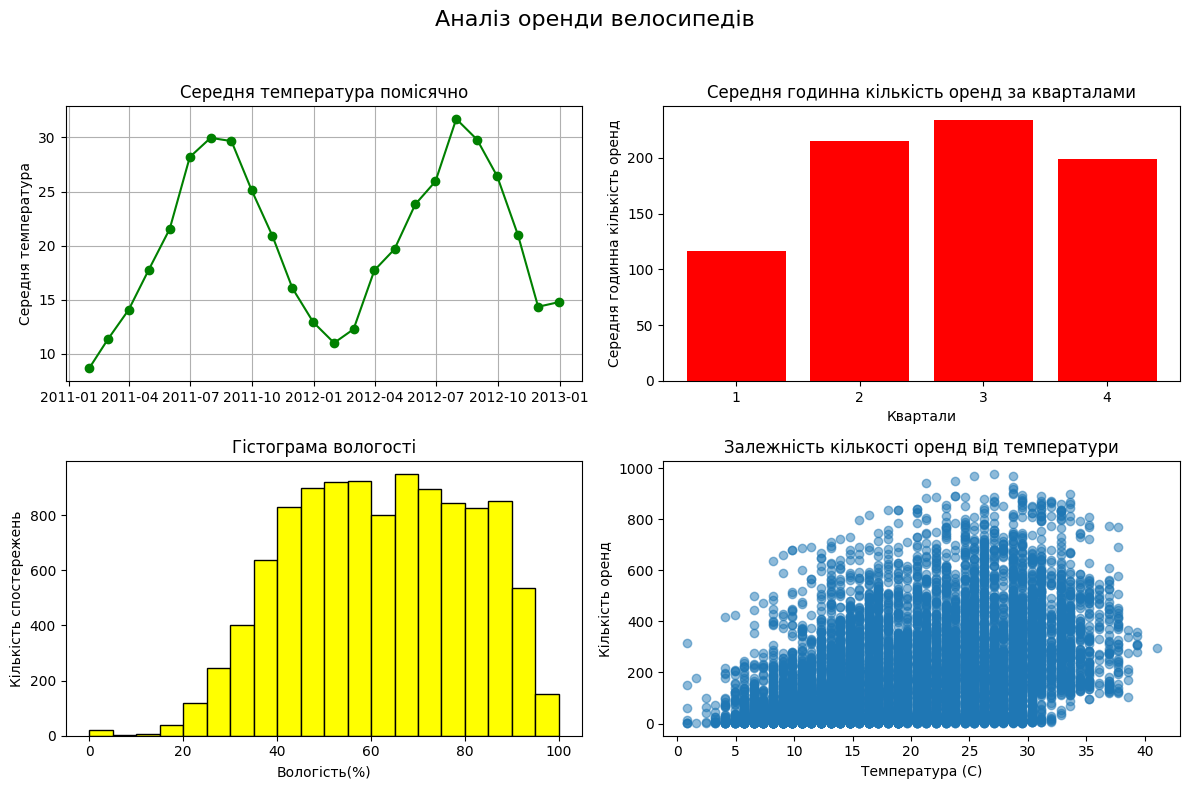

In [165]:
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.plot(avg_temp,marker='o',color='green')
plt.title('Середня температура помісячно')
plt.ylabel('Середня температура')
plt.grid(True)

plt.subplot(2,2,2)
plt.bar(avg_quarter.index,avg_quarter.values, color='red')
plt.title('Середня годинна кількість оренд за кварталами')
plt.xlabel('Квартали')
plt.ylabel('Середня годинна кількість оренд')

plt.xticks([1,2,3,4])

plt.subplot(2,2,3)
plt.hist(df['humidity'],bins=20, color='yellow', edgecolor='black')
plt.title('Гістограма вологості')
plt.xlabel('Вологість(%)')
plt.ylabel('Кількість спостережень')

plt.subplot(2,2,4)
plt.scatter(df['temp'],df['count'],alpha=0.5)
plt.title('Залежність кількості оренд від температури')
plt.xlabel('Температура (С)')
plt.ylabel('Кількість оренд')


plt.suptitle('Аналіз оренди велосипедів', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

Різниця в підході.
Для plt.subploat потрібно менше ходу, швидкий та простий для невеликих графіків.Ми створюємо фігуру, а після цього по черзі активуємо кожну панель викликами, код працює з поточною віссю, яку ви щорозу явно перемикаємо.
Plt.subploats більш сучасний - ми створюємо фігуру й отримаємо змінну ах - масив або матрицю об'єктів Axes, кожен з яких — окрема панель для графіка. Зручно масштабувати,простий доступ до кожного графіка, простіше стилізувати.


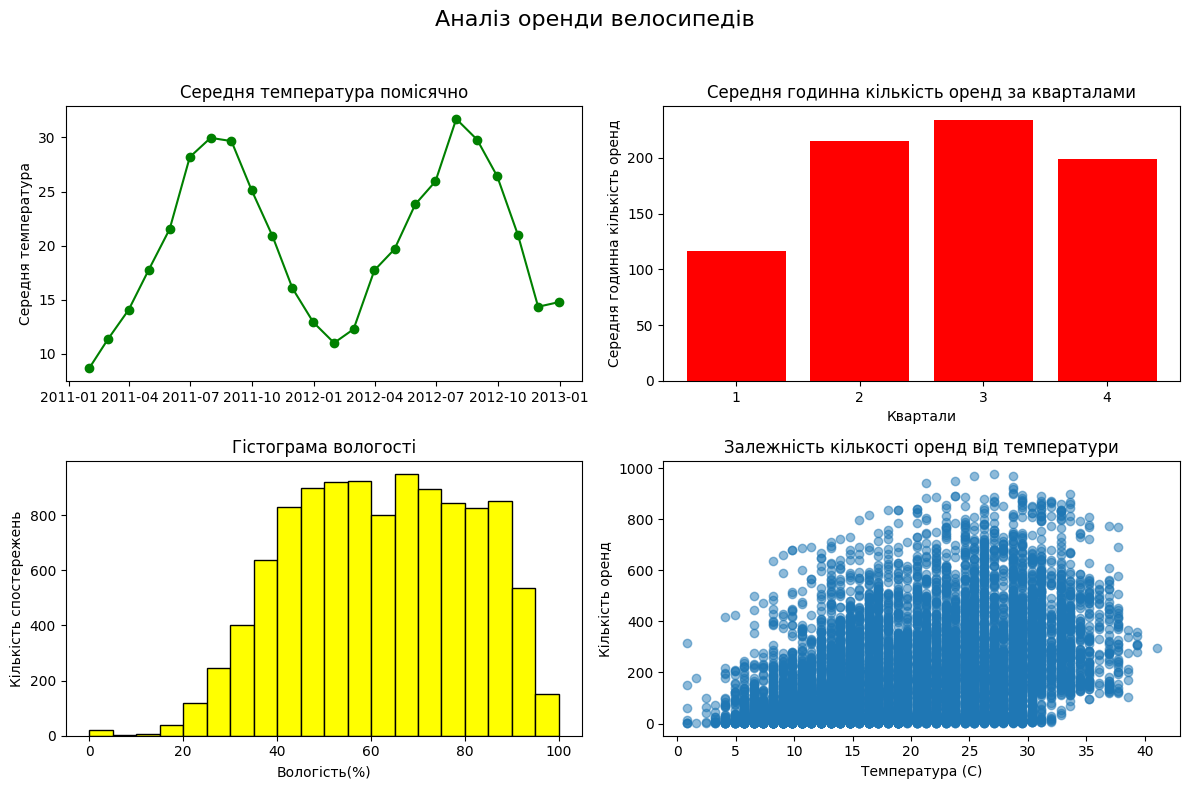

In [169]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(avg_temp,marker='o', color='green')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_ylabel('Середня температура')


ax[0, 1].bar(avg_quarter.index,avg_quarter.values, color='red')
ax[0, 1].set_title('Середня годинна кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартали')
ax[0, 1].set_ylabel('Середня годинна кількість оренд')
ax[0,1].set_xticks([1,2,3,4])


ax[1, 0].hist(df['humidity'],bins=20, color='yellow', edgecolor='black')
ax[1, 0].set_title('Гістограма вологості')
ax[1, 0].set_xlabel('Вологість(%)')
ax[1, 0].set_ylabel('Кількість спостережень')


ax[1, 1].scatter(df['temp'],df['count'],alpha=0.5)
ax[1, 1].set_title('Залежність кількості оренд від температури')
ax[1, 1].set_xlabel('Температура (С)')
ax[1, 1].set_ylabel('Кількість оренд')


fig.suptitle('Аналіз оренди велосипедів', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

1. Це дає нам змогу зробити більш зрозумілий та читабельний графік, вся ключова інформація - візуалізована. Особливо, коли графік дивитимуться без пояснень, цей звіт для керівника.
2. Використовуємо для створення заливки міжь двома лініями.
3. Дані стають зрозумілими для швидшого аналізу та прийняття рішень.

In [170]:
import matplotlib.dates as mdates

In [180]:
monthly_stats = df['count'].resample('ME').agg(['mean','max','min'])

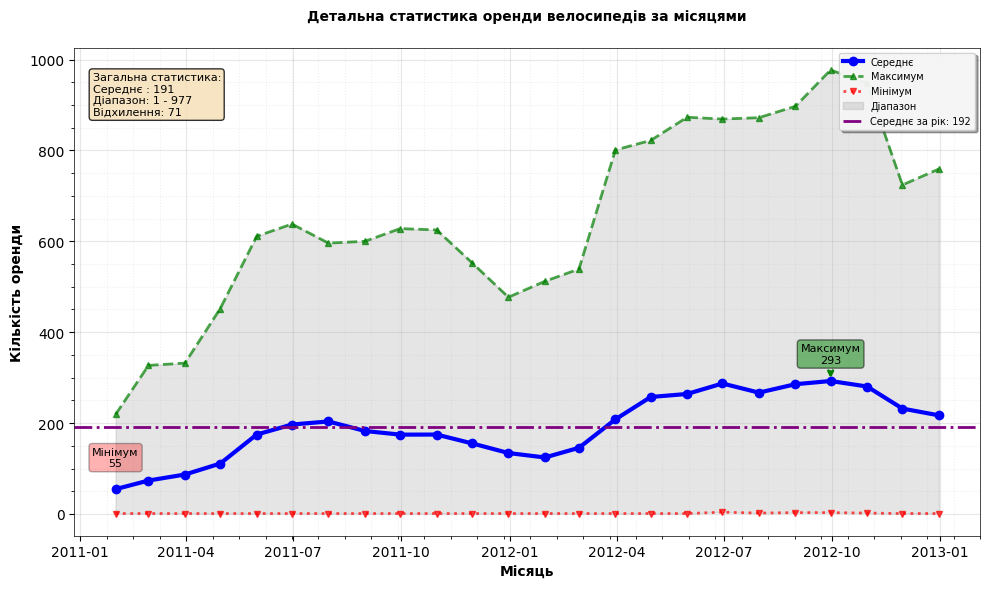

In [261]:
fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=6)
ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^', linewidth=2,
        label='Максимум', markersize=5, alpha=0.7)
ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=5, alpha=0.7)


ax.fill_between(monthly_stats.index, monthly_stats['min'], monthly_stats['max'],
                alpha=0.2, color='gray', label='Діапазон')


min_idx = monthly_stats['mean'].idxmin()
min_val = monthly_stats['mean'].min()
ax.annotate(f'Мінімум\n{min_val:.0f}',
            xy=(min_idx, min_val), xytext=(min_idx, min_val + 50),
            fontsize=8, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='red', alpha=0.3))


max_idx = monthly_stats['mean'].idxmax()
max_val = monthly_stats['mean'].max()
ax.annotate(f'Максимум\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 40),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=8, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='green', alpha=0.5))


ax.set_xlabel('Місяць', fontsize=10, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=10, fontweight='bold')
ax.set_title('Детальна статистика оренди велосипедів за місяцями',
             fontsize=10, fontweight='bold', pad=20)



ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()


overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')


ax.legend(loc='upper right', fontsize=7, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)


textstr = f'Загальна статистика:\n'
textstr += f'Середнє : {(monthly_stats["mean"]).mean():.0f}\n'
textstr += f'Діапазон: {monthly_stats["min"].min():.0f} - {monthly_stats["max"].max():.0f}\n'
textstr += f'Відхилення: {(monthly_stats["mean"] - monthly_stats["min"]).std(ddof=1):.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', bbox=props)


for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

